        Date  Store  Item  Sales Region
0 2023-01-01      2     3    117  North
1 2023-01-02      1     1    159  North
2 2023-01-03      4     1    107  North
3 2023-01-04      3     4     46  South
4 2023-01-05      4     1    117  North
Date      0
Store     0
Item      0
Sales     0
Region    0
dtype: int64
count    100.000000
mean     101.370000
std       52.309038
min       23.000000
25%       56.000000
50%      102.500000
75%      141.250000
max      193.000000
Name: Sales, dtype: float64
10137
101.37
193
23


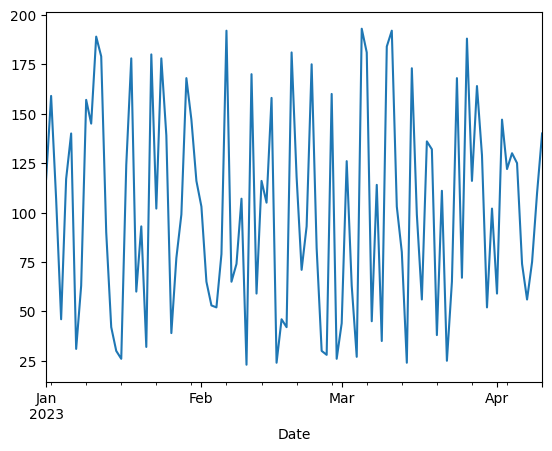

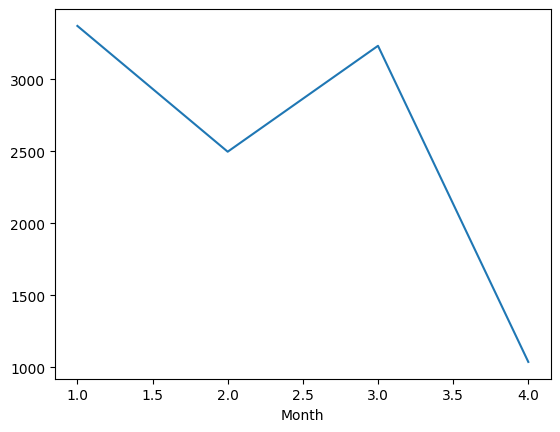

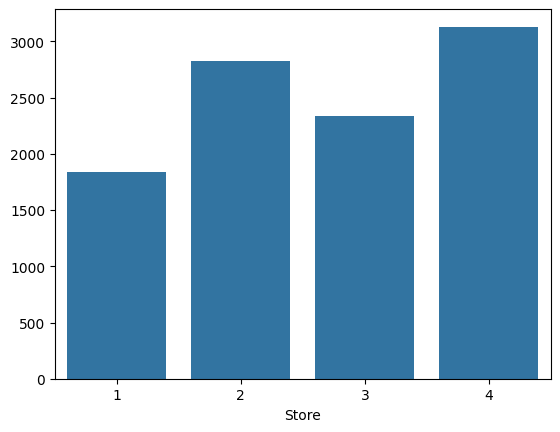

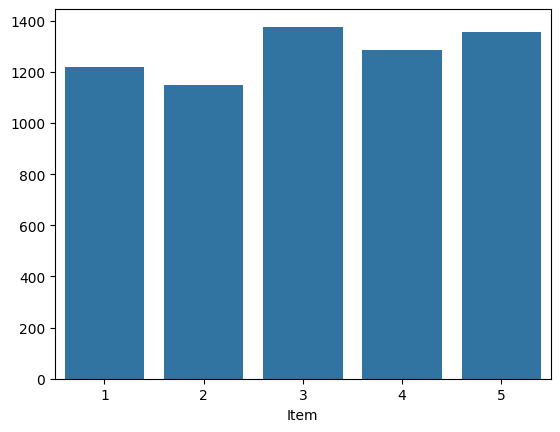

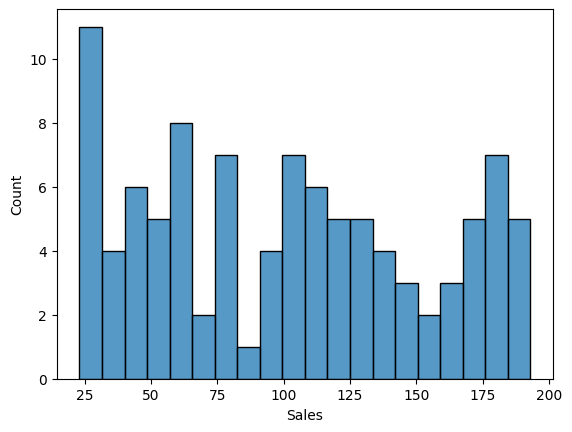

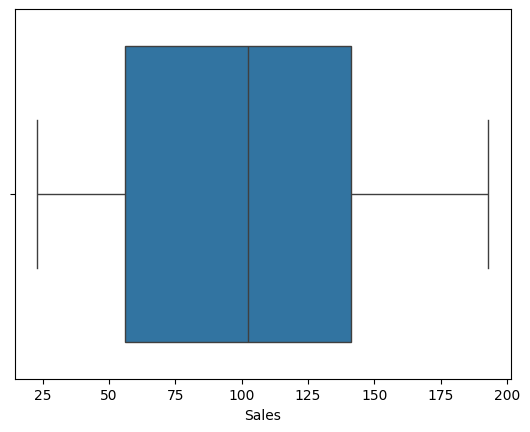

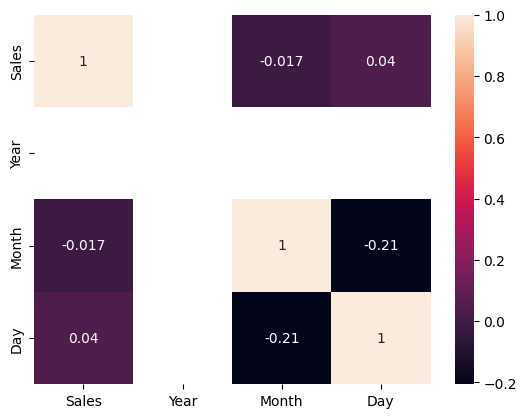

4
1
3
6
1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


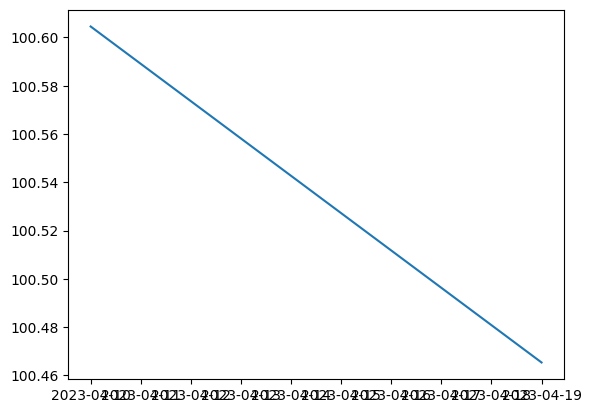

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Date": pd.date_range(start="2023-01-01", periods=100),
    "Store": np.random.randint(1, 5, 100),
    "Item": np.random.randint(1, 10, 100),
    "Sales": np.random.randint(20, 200, 100),
    "Region": np.random.choice(["North", "South", "East", "West"], 100)
}

df = pd.DataFrame(data)

print(df.head())

df['Date'] = pd.to_datetime(df['Date'])
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

print(df['Sales'].describe())
print(df['Sales'].sum())
print(df['Sales'].mean())
print(df['Sales'].max())
print(df['Sales'].min())

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

daily_sales = df.groupby('Date')['Sales'].sum()
plt.figure()
daily_sales.plot()
plt.show()

monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.show()

store_sales = df.groupby('Store')['Sales'].sum()
plt.figure()
sns.barplot(x=store_sales.index, y=store_sales.values)
plt.show()

item_sales = df.groupby('Item')['Sales'].sum()
top_products = item_sales.sort_values(ascending=False).head(5)
plt.figure()
sns.barplot(x=top_products.index, y=top_products.values)
plt.show()

plt.figure()
sns.histplot(df['Sales'], bins=20)
plt.show()

plt.figure()
sns.boxplot(x=df['Sales'])
plt.show()

plt.figure()
corr = df[['Sales', 'Year', 'Month', 'Day']].corr()
sns.heatmap(corr, annot=True)
plt.show()

print(store_sales.idxmax())
print(store_sales.idxmin())
print(item_sales.idxmax())
print(item_sales.idxmin())
print(monthly_sales.idxmax())

from sklearn.linear_model import LinearRegression

df['Date_Ordinal'] = df['Date'].map(pd.Timestamp.toordinal)

X = df[['Date_Ordinal']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

future_dates = pd.date_range(start=df['Date'].max(), periods=10)
future_ord = future_dates.map(pd.Timestamp.toordinal)

pred = model.predict(future_ord.values.reshape(-1, 1))

plt.figure()
plt.plot(future_dates, pred)
plt.show()